# Training Patch Classifiers from Per-Class Patch Folders

Click to open in: [[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)][[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)]


## About this notebook

This Jupyter notebook can run on a local Python environment or on Google Colab. If you run it on Colab, use the installation cell below and restart the runtime once installation finishes.


## About this demo

This example demonstrates model training for **case 1** in the training roadmap: per-class patch folders where each subfolder name defines the target class.

You will:

1. Download the small Kather 100K patch subset used in `05-patch-prediction.ipynb`.
1. Build a `PatchFolderClassificationDataset` from the folder structure.
1. Split the dataset with the TIAToolbox `stratified_split_indices` helper.
1. Train a `CNNModel` with a `resnet18` backbone using `Trainer` and `ClassificationTask`.
1. Inspect generated checkpoints and resume training from `last.ckpt`.


## Optional: Colab setup

Skip this section when running in an environment where `tiatoolbox` is already installed.


In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools openslide-tools libpixman-1-dev | tail -n 1
pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
echo "Installation is done."


If you are using Colab and ran the installation cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import zarr
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from zipfile import ZipFile

from tiatoolbox.models.architecture.vanilla import CNNModel
from tiatoolbox.models.dataset import predefined_preproc_func
from tiatoolbox.models.engine.patch_predictor import PatchPredictor
from tiatoolbox.models.training import (
    ClassificationTask,
    PatchFolderClassificationDataset,
    Trainer,
    TrainerConfig,
    stratified_split_indices,
)
from tiatoolbox.utils.misc import download_data, imread, imwrite

plt.rcParams["figure.dpi"] = 160
plt.rcParams["figure.facecolor"] = "white"

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Use the Kather 100K patch subset

We reuse the same small Kather patch subset downloaded in `05-patch-prediction.ipynb`. The dataset already follows the per-class folder structure expected by `PatchFolderClassificationDataset`.


In [6]:
kather_class_to_idx = {
    "BACK": 0,
    "NORM": 1,
    "DEB": 2,
    "TUM": 3,
    "ADI": 4,
    "MUC": 5,
    "MUS": 6,
    "STR": 7,
    "LYM": 8,
}
class_names = list(kather_class_to_idx)

global_save_dir = Path("tmp")
global_save_dir.mkdir(parents=True, exist_ok=True)
patches_file_name = global_save_dir / "kather100k-validation-sample.zip"
dataset_root = global_save_dir / "kather100k-validation-sample"

if not patches_file_name.exists():
    dataset_root = download_data(
        "https://tiatoolbox.dcs.warwick.ac.uk/datasets/kather100k-validation-sample.zip",
        save_path=patches_file_name,
    )
# Unzip it!
with ZipFile(patches_file_name, "r") as zipfile:
    zipfile.extractall(path=global_save_dir)

sample_image = imread(next((dataset_root / class_names[0]).glob("*.tif")))
patch_size = sample_image.shape[0]

print(f"Dataset path: {dataset_root.resolve()}")
print(f"Patch size: {patch_size}px")
for class_name in class_names:
    patch_count = len(list((dataset_root / class_name).glob("*.tif")))
    print(f"{class_name}: {patch_count} patches")

Dataset path: /media/mark-eastwood/Work/tiatoolbox/examples/tmp/kather100k-validation-sample
Patch size: 224px
BACK: 211 patches
NORM: 176 patches
DEB: 230 patches
TUM: 286 patches
ADI: 208 patches
MUC: 178 patches
MUS: 270 patches
STR: 209 patches
LYM: 232 patches


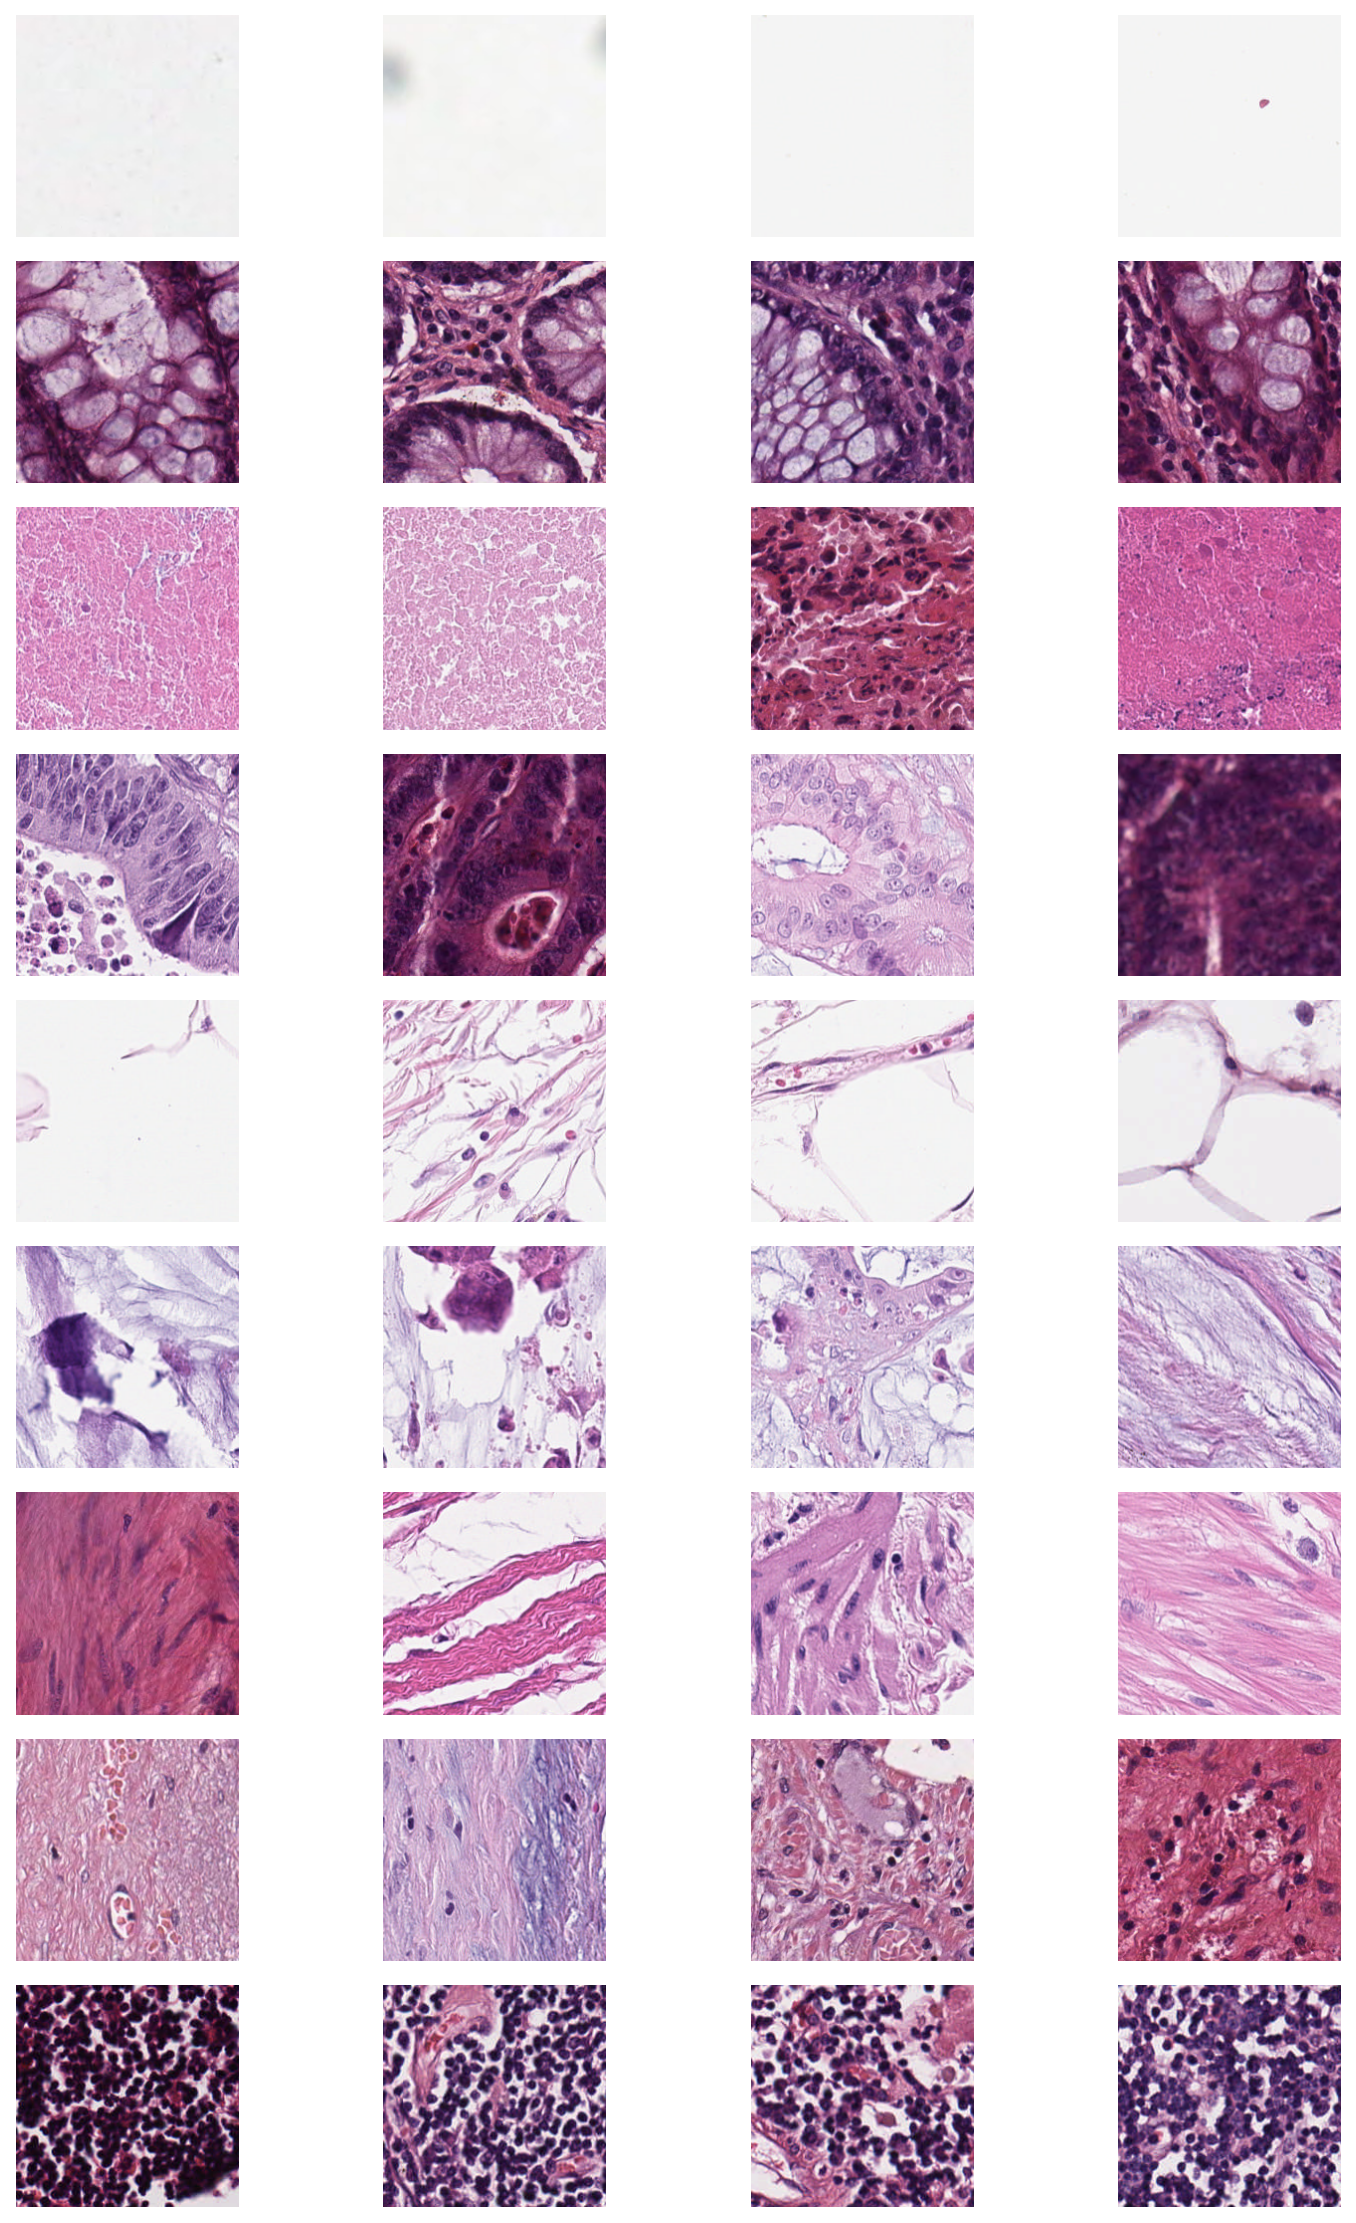

In [7]:
fig, axes = plt.subplots(len(class_names), 4, figsize=(10, 14))
for row_index, class_name in enumerate(class_names):
    sample_paths = sorted((dataset_root / class_name).glob("*.tif"))[:4]
    for col_index, sample_path in enumerate(sample_paths):
        image = imread(sample_path)
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].axis("off")
    axes[row_index, 0].set_ylabel(class_name, rotation=90, size=10)

plt.tight_layout()

## Build dataset and dataloaders


In [8]:
dataset = PatchFolderClassificationDataset(
    root_dir=dataset_root,
    class_to_idx=kather_class_to_idx,
)
print(f"Total patches: {len(dataset)}")
print("Class mapping:", dataset.class_to_idx)

train_indices, val_indices = stratified_split_indices(
    [target for _, target in dataset.samples],
    val_fraction=0.2,
    seed=5,
)

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

print(f"Train patches: {len(train_dataset)}")
print(f"Val patches:   {len(val_dataset)}")

Total patches: 2000
Class mapping: {'BACK': 0, 'NORM': 1, 'DEB': 2, 'TUM': 3, 'ADI': 4, 'MUC': 5, 'MUS': 6, 'STR': 7, 'LYM': 8}
Train patches: 1600
Val patches:   400


In [9]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Image batch shape:", tuple(batch["image"].shape))
print("Target batch shape:", tuple(batch["target"].shape))
print("Image dtype:", batch["image"].dtype)
print("Target dtype:", batch["target"].dtype)

Image batch shape: (16, 3, 224, 224)
Target batch shape: (16,)
Image dtype: torch.float32
Target dtype: torch.int64


## Define model and trainer

We use TIAToolbox's `CNNModel` with a vanilla `resnet18` backbone rather than defining a custom classifier inline.


In [ ]:
num_classes = len(dataset.class_to_idx)


def build_model(num_output_classes, class_to_idx):
    model = CNNModel("resnet18", num_classes=num_output_classes)
    model.preproc_func = predefined_preproc_func("kather100k")
    model.class_dict = {index: name for name, index in class_to_idx.items()}
    return model


model = build_model(num_classes, dataset.class_to_idx)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-5)

output_dir = Path("tmp/patch_folder_training_run")
output_dir.mkdir(parents=True, exist_ok=True)

trainer = Trainer(
    model=model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=5,
        device=device,
        amp=device == "cuda",
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

## Train the model


In [19]:
history = trainer.fit()
print(f"Finished epochs: {len(history)}")
print(f"Best epoch: {trainer.best_epoch}")
history[-1]


|2026-03-15|17:56:30.218| [INFO] Epoch 1/5 | monitor `val_loss`=2.092484 | best=2.092484
|2026-03-15|17:56:33.933| [INFO] Epoch 2/5 | monitor `val_loss`=1.315048 | best=1.315048
|2026-03-15|17:56:39.597| [INFO] Epoch 3/5 | monitor `val_loss`=3.444888 | best=1.315048
|2026-03-15|17:56:43.447| [INFO] Epoch 4/5 | monitor `val_loss`=1.090896 | best=1.090896
|2026-03-15|17:56:48.391| [INFO] Epoch 5/5 | monitor `val_loss`=0.773186 | best=0.773186
Finished epochs: 5
Best epoch: 5


{'epoch': 5.0,
 'train_loss': 0.8559410285949707,
 'train_accuracy': 0.6875,
 'train_f1': 0.5694165464165464,
 'val_loss': 0.7731858825683594,
 'val_accuracy': 0.685,
 'val_f1': 0.5276552829886163}

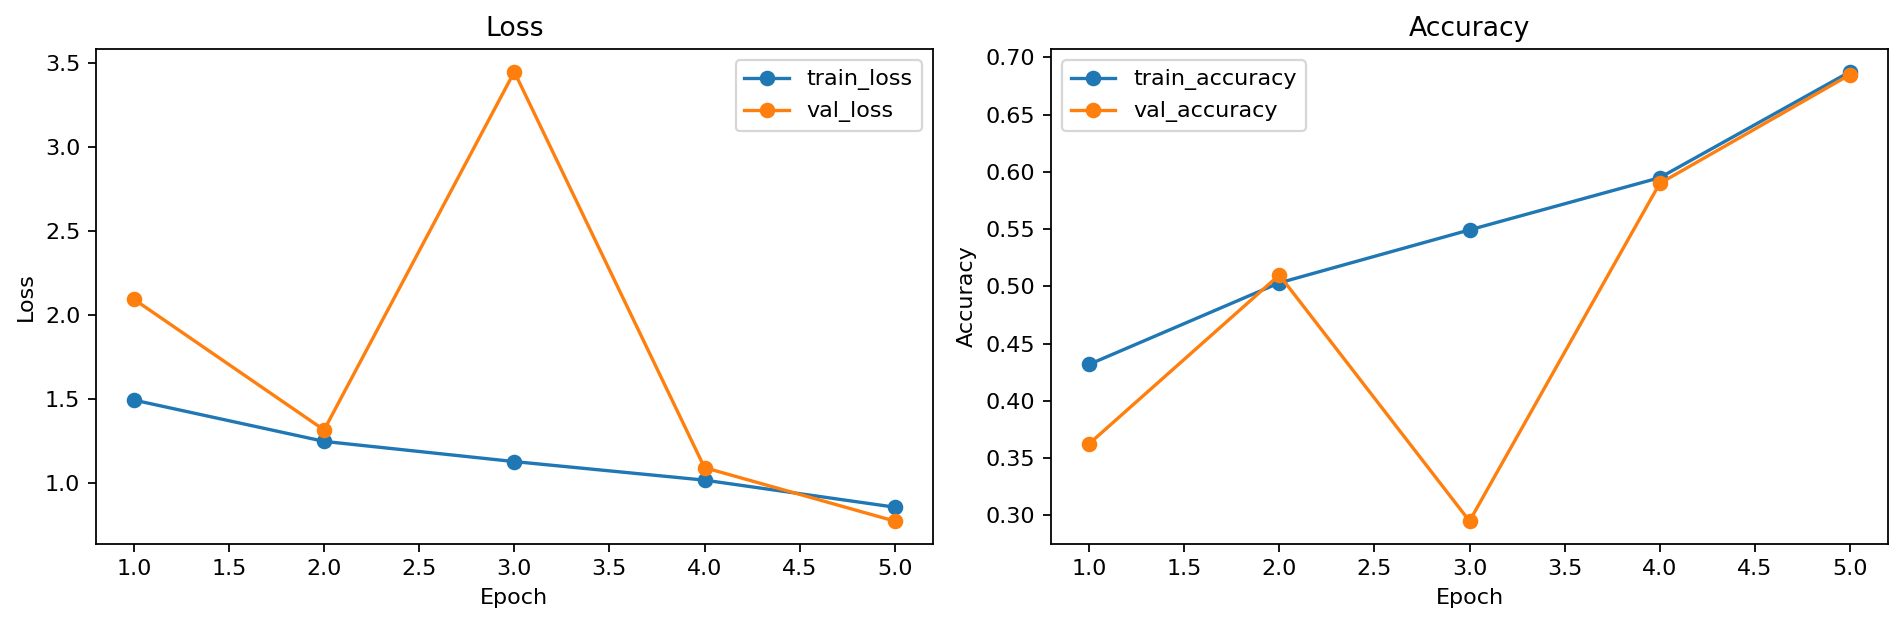

In [20]:
epochs = [int(record["epoch"]) for record in history]
train_loss = [record["train_loss"] for record in history]
val_loss = [record.get("val_loss", np.nan) for record in history]
train_acc = [record["train_accuracy"] for record in history]
val_acc = [record.get("val_accuracy", np.nan) for record in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="train_loss")
axes[0].plot(epochs, val_loss, marker="o", label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_acc, marker="o", label="train_accuracy")
axes[1].plot(epochs, val_acc, marker="o", label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()


## Checkpoints and resume

`Trainer` writes `last.ckpt` (full state) and `best_model_weights.pth` (weights only).


In [ ]:
print("Saved checkpoint artifacts:")
for path in sorted(output_dir.glob("*")):
    print("-", path.name)

resumed_model = build_model(num_classes, dataset.class_to_idx)
resumed_optimizer = torch.optim.AdamW(
    resumed_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4,
)
resumed_scheduler = CosineAnnealingLR(
    resumed_optimizer,
    T_max=5,
    eta_min=1e-5,
)

resumed_trainer = Trainer(
    model=resumed_model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=resumed_optimizer,
    scheduler=resumed_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=10,
        device=device,
        amp=device == "cuda",
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

resumed_history = resumed_trainer.fit(resume_from=output_dir / "last.ckpt")
print(f"Resumed to epoch: {int(resumed_history[-1]['epoch'])}")

Saved checkpoint artifacts:
- best_model_weights.pth
- last.ckpt
- patchpredictor_output
- stitched_large_image.png
|2026-03-15|17:56:48.625| [INFO] Resumed training from checkpoint `tmp/patch_folder_training_run/last.ckpt` at epoch 5.
|2026-03-15|17:56:53.249| [INFO] Epoch 6/10 | monitor `val_loss`=0.663644 | best=0.663644
|2026-03-15|17:56:57.711| [INFO] Epoch 7/10 | monitor `val_loss`=1.336374 | best=0.663644
|2026-03-15|17:57:02.617| [INFO] Epoch 8/10 | monitor `val_loss`=3.491209 | best=0.663644
|2026-03-15|17:57:08.787| [INFO] Epoch 9/10 | monitor `val_loss`=1.308042 | best=0.663644
|2026-03-15|17:57:12.753| [INFO] Epoch 10/10 | monitor `val_loss`=2.015063 | best=0.663644
Resumed to epoch: 10


## Inference on a stitched large image with `PatchPredictor`

We now reuse the trained `CNNModel` inside the TIAToolbox `PatchPredictor` engine. A larger image is built by stitching Kather patches into a grid, and `PatchPredictor` extracts and classifies tiles in `patch_mode=False`.


(np.float64(-0.5), np.float64(2015.5), np.float64(1343.5), np.float64(-0.5))

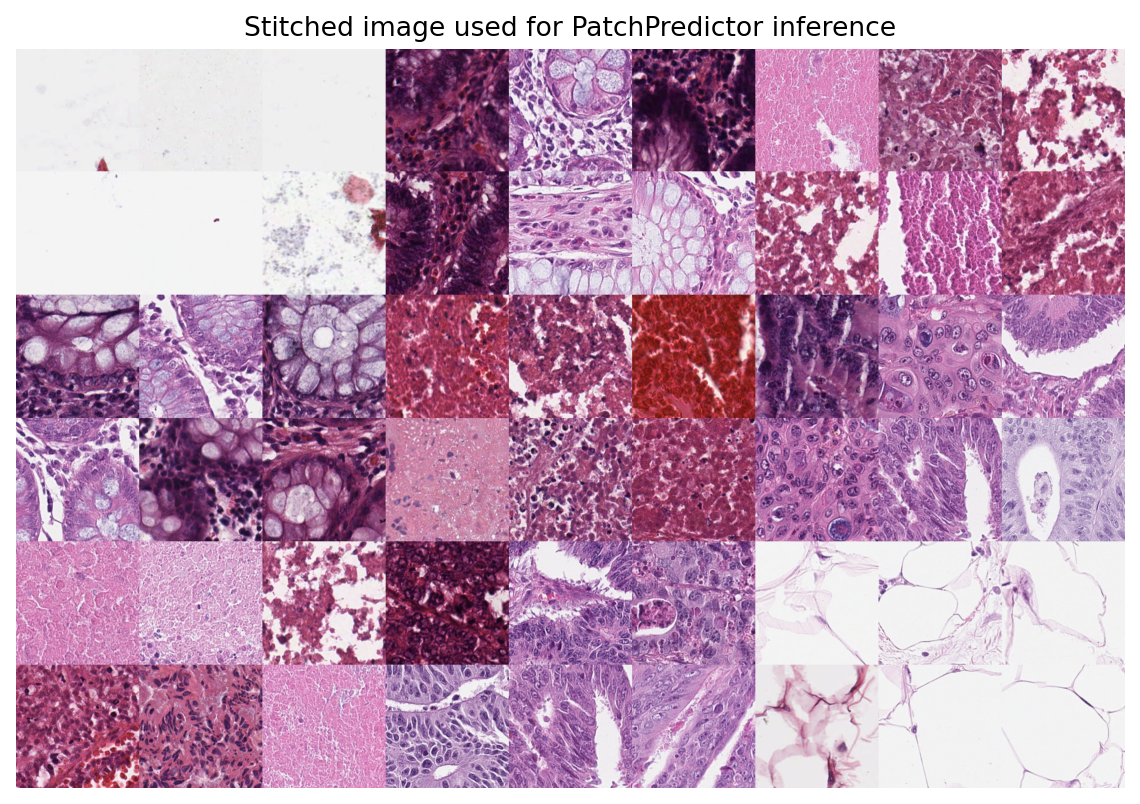

In [22]:
grid_rows, grid_cols = 6, 9
class_names = [name for name, _ in sorted(dataset.class_to_idx.items(), key=lambda item: item[1])]
rng = np.random.default_rng(21)

stitched_image = np.zeros((grid_rows * patch_size, grid_cols * patch_size, 3), dtype=np.uint8)
expected_index_map = np.zeros((grid_rows, grid_cols), dtype=np.int64)

for row in range(grid_rows):
    for col in range(grid_cols):
        class_name = class_names[(row // 2 + col // 3) % len(class_names)]
        expected_index_map[row, col] = dataset.class_to_idx[class_name]
        patch_candidates = sorted((dataset_root / class_name).glob("*.tif"))
        patch_path = patch_candidates[int(rng.integers(len(patch_candidates)))]
        patch = imread(patch_path)

        y0, y1 = row * patch_size, (row + 1) * patch_size
        x0, x1 = col * patch_size, (col + 1) * patch_size
        stitched_image[y0:y1, x0:x1] = patch

stitched_image_path = output_dir / "stitched_large_image.png"
imwrite(stitched_image_path, stitched_image)

plt.figure(figsize=(12, 6))
plt.imshow(stitched_image)
plt.title("Stitched image used for PatchPredictor inference")
plt.axis("off")

In [23]:
inference_model = build_model(num_classes, dataset.class_to_idx)

predictor = PatchPredictor(
    model=inference_model,
    weights=output_dir / "best_model_weights.pth",
    batch_size=16,
    num_workers=0,
    device=device,
    verbose=False,
)

predictor_output_dir = output_dir / "patchpredictor_output"

predictor_output = predictor.run(
    images=[stitched_image_path],
    patch_mode=False,
    patch_input_shape=(patch_size, patch_size),
    stride_shape=(patch_size, patch_size),
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    auto_get_mask=False,
    return_probabilities=True,
    overwrite=True,
    output_type="zarr",
    save_dir=predictor_output_dir,
)

zarr_output_path = predictor_output[stitched_image_path]
print(f"PatchPredictor output: {zarr_output_path}")

|2026-03-15|17:57:14.106| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.
|2026-03-15|17:57:14.107| [WARNING] Please provide a valid ModelIOConfigABC. No default ModelIOConfigABC found.


|2026-03-15|17:57:14.107| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


|2026-03-15|17:57:14.143| [WARNING] Raw data is None.
|2026-03-15|17:57:14.144| [WARNING] Unknown scale (no objective_power or mpp)
|2026-03-15|17:57:14.179| [WARNING] Raw data is None.
|2026-03-15|17:57:14.179| [WARNING] Unknown scale (no objective_power or mpp)


|2026-03-15|17:57:14.258| [INFO] Output file saved at tmp/patch_folder_training_run/patchpredictor_output/stitched_large_image.zarr.
PatchPredictor output: tmp/patch_folder_training_run/patchpredictor_output/stitched_large_image.zarr


Tile-level accuracy on stitched image: 0.722


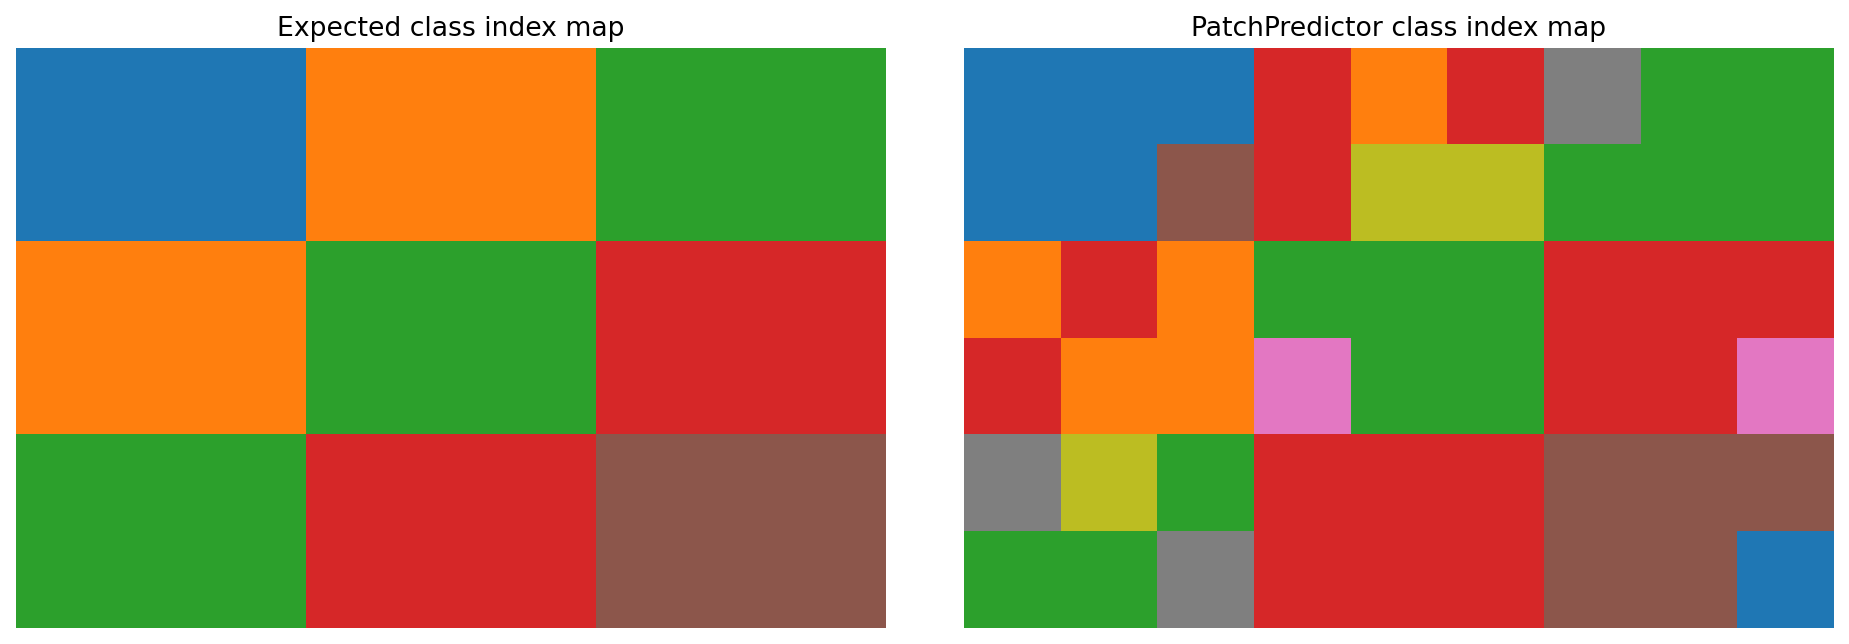

In [24]:
zarr_output = zarr.open(zarr_output_path, mode="r")
predictions = np.array(zarr_output["predictions"])
coordinates = np.array(zarr_output["coordinates"])

predicted_index_map = np.full((grid_rows, grid_cols), fill_value=-1, dtype=np.int64)
for pred_idx, (x0, y0, _, _) in zip(predictions, coordinates):
    row = int(y0 // patch_size)
    col = int(x0 // patch_size)
    predicted_index_map[row, col] = int(pred_idx)

tile_accuracy = float((predicted_index_map == expected_index_map).mean())
print(f"Tile-level accuracy on stitched image: {tile_accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(expected_index_map, cmap="tab10", vmin=0, vmax=num_classes - 1)
axes[0].set_title("Expected class index map")
axes[0].axis("off")

axes[1].imshow(predicted_index_map, cmap="tab10", vmin=0, vmax=num_classes - 1)
axes[1].set_title("PatchPredictor class index map")
axes[1].axis("off")

plt.tight_layout()


## Adapting this notebook to real data

Replace `dataset_root` with your own patch directory:

```text
my_patch_dataset/
  class_a/
    patch_0001.png
    patch_0002.png
  class_b/
    patch_0003.png
```

If you want a stable label order, pass your own `class_to_idx` mapping into `PatchFolderClassificationDataset`, then keep the same dataloaders, `CNNModel`, and `Trainer` workflow.
